In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/mec02_data_centres.csv")
df

,Statistic Label,Quarter,Electricity Consumption,UNIT,VALUE
0,Gigawatt hours,2015Q1,All metered electricity consumption,GWh,6565
1,Gigawatt hours,2015Q1,Data centres,GWh,291
2,Gigawatt hours,2015Q1,Customers other than data centres,GWh,6274
3,Gigawatt hours,2015Q2,All metered electricity consumption,GWh,6086
4,Gigawatt hours,2015Q2,Data centres,GWh,304
...,...,...,...,...,...
127,Gigawatt hours,2025Q3,Data centres,GWh,1956
128,Gigawatt hours,2025Q3,Customers other than data centres,GWh,5778
129,Gigawatt hours,2025Q4,All metered electricity consumption,GWh,8420
130,Gigawatt hours,2025Q4,Data centres,GWh,1991


In [3]:
wide = df.pivot(index="Quarter", columns = "Electricity Consumption", values= "VALUE",)
wide

Electricity Consumption,All metered electricity consumption,Customers other than data centres,Data centres
Quarter,,,
2015Q1,6565,6274,291
2015Q2,6086,5783,304
2015Q3,5783,5467,316
2015Q4,6165,5836,329
2016Q1,6651,6310,341
2016Q2,6471,6111,361
2016Q3,5926,5540,386
2016Q4,6307,5912,395
2017Q1,6867,6460,407


In [4]:
wide = wide.rename(columns={
    "All metered electricity consumption": "total",
    "Customers other than data centres": "others",
    "Data centres": "data_centres"
})
wide

Electricity Consumption,total,others,data_centres
Quarter,,,
2015Q1,6565,6274,291
2015Q2,6086,5783,304
2015Q3,5783,5467,316
2015Q4,6165,5836,329
2016Q1,6651,6310,341
2016Q2,6471,6111,361
2016Q3,5926,5540,386
2016Q4,6307,5912,395
2017Q1,6867,6460,407


In [5]:
wide["dc_share"] = wide["data_centres"] / wide["total"] * 100
wide.round(1)

Electricity Consumption,total,others,data_centres,dc_share
Quarter,,,,
2015Q1,6565,6274,291,4.4
2015Q2,6086,5783,304,5.0
2015Q3,5783,5467,316,5.5
2015Q4,6165,5836,329,5.3
2016Q1,6651,6310,341,5.1
2016Q2,6471,6111,361,5.6
2016Q3,5926,5540,386,6.5
2016Q4,6307,5912,395,6.3
2017Q1,6867,6460,407,5.9


In [6]:
wide["year"] = wide.index.str[:4]
yearly = wide.groupby("year")[["data_centres", "others", "total"]].sum()
yearly["dc_share"] = yearly["data_centres"] / yearly["total"] * 100
yearly.round(1)

Electricity Consumption,data_centres,others,total,dc_share
year,,,,
2015,1240,23360,24599,5.0
2016,1483,23873,25355,5.8
2017,1762,23963,25726,6.8
2018,2183,24548,26730,8.2
2019,2489,24016,26504,9.4
2020,3031,24026,27056,11.2
2021,4013,24494,28506,14.1
2022,5274,24552,29825,17.7
2023,6339,24242,30581,20.7


how fast did each group grow each year??

In [7]:

yearly["dc_growth"] = yearly["data_centres"].pct_change() * 100
yearly["others_growth"] = yearly["others"].pct_change() * 100
yearly.round(1)

Electricity Consumption,data_centres,others,total,dc_share,dc_growth,others_growth
year,,,,,,
2015,1240,23360,24599,5.0,NaN,NaN
2016,1483,23873,25355,5.8,19.6,2.2
2017,1762,23963,25726,6.8,18.8,0.4
2018,2183,24548,26730,8.2,23.9,2.4
2019,2489,24016,26504,9.4,14.0,-2.2
2020,3031,24026,27056,11.2,21.8,0.0
2021,4013,24494,28506,14.1,32.4,1.9
2022,5274,24552,29825,17.7,31.4,0.2
2023,6339,24242,30581,20.7,20.2,-1.3


2015 year shows it as NaN , because we dont have the 2014 data to compare the growth 

In 2025, share 23.2% - CSO says 23% 
         data centre growth 9.9% - CSO says 10 %
         others growth 1.6% - CSO says 2% 

Clearly , data centre demand grew upto 6 times faster than everyone else !! 

IS it speeding up or slowing down ??

In 2021, the regulator restricted new data centre connections in Dublin

By reading the dc_growth, we can see :

 2016 to 2020 - the growth is fast!, 
 2021 and 2022 - PEAK [Fastest growth in whole dataset],
 2023 - Drops to 20%, 
 2024 and 2025 - About 10% a year. 





### Growth is slowing down, and the slowdown starts right after the 2021 Dublin restrictions

### My honest takings here :

### 1. The timing is never the proof - 
slowdown matches the restrictions happened in 2021 , but it could also explain other things that happened in other years too ! 
### Other things could also explain the slowdown 
### The timing matches, but this data alone can't prove whether the restrictions caused the slowdown! 

### 2. Slower does not mean smaller - 
Growth slowed from 32% to 10%, but data centres still added about 690 GWh in 2025, and their share keeps rising every single year.
### The problem is growing more slowly, not going away.

In [8]:
import matplotlib.pyplot as plt



Matplotlib is building the font cache; this may take a moment.


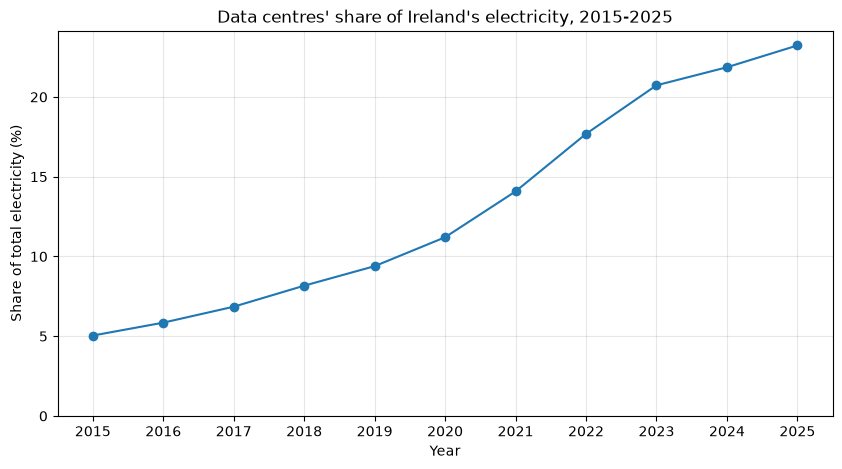

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly.index, yearly["dc_share"], marker="o")
ax.set_title("Data centres' share of Ireland's electricity, 2015-2025")
ax.set_xlabel("Year")
ax.set_ylabel("Share of total electricity (%)")
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)
plt.savefig("../charts/01_dc_share.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
cols = ["data_centres", "others"]
indexed = yearly[cols] / yearly[cols].iloc[0] * 100
indexed.round(1)

Electricity Consumption,data_centres,others
year,,
2015,100.0,100.0
2016,119.6,102.2
2017,142.1,102.6
2018,176.0,105.1
2019,200.7,102.8
2020,244.4,102.9
2021,323.6,104.9
2022,425.3,105.1
2023,511.2,103.8


We can clearly see here , data centres electricity grew by almost 518% compared to where others electricity grew only 8%

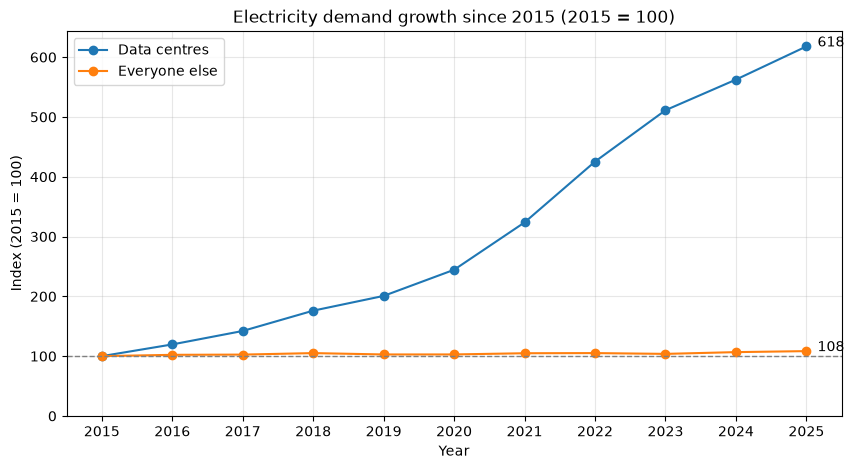

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(indexed.index, indexed["data_centres"], marker="o", label="Data centres")
ax.plot(indexed.index, indexed["others"], marker="o", label="Everyone else")
ax.axhline(100, color="grey", linestyle="--", linewidth=1)
ax.set_title("Electricity demand growth since 2015 (2015 = 100)")
ax.set_xlabel("Year")
ax.set_ylabel("Index (2015 = 100)")
ax.set_ylim(bottom=0)
ax.legend()
ax.grid(alpha=0.3)
ax.annotate(f"{indexed['data_centres'].iloc[-1]:.0f}", (indexed.index[-1], indexed["data_centres"].iloc[-1]), xytext=(8, 0), textcoords="offset points")
ax.annotate(f"{indexed['others'].iloc[-1]:.0f}", (indexed.index[-1], indexed["others"].iloc[-1]), xytext=(8, 0), textcoords="offset points")
ax.margins(x=0.05)
plt.savefig("../charts/02_growth_index.png", dpi=150, bbox_inches="tight")
plt.show()

### Where is it heading? 

Showing it in the Scenario projection (Growth rate) 

In [19]:
years = 10
dc_cagr = (yearly["data_centres"].iloc[-1] / yearly["data_centres"].iloc[0]) ** (1 / years) - 1
others_cagr = (yearly["others"].iloc[-1] / yearly["others"].iloc[0]) ** (1 / years) - 1

print(f"Data centres, 10-year CAGR: {dc_cagr * 100:.1f}%")
print(f"Everyone else, 10-year CAGR: {others_cagr * 100:.1f}%")

Data centres, 10-year CAGR: 20.0%
Everyone else, 10-year CAGR: 0.8%


Now, projecting 3 scenarios to 2030

In [20]:
base_dc = yearly["data_centres"].iloc[-1]
base_others = yearly["others"].iloc[-1]
scenarios = {"Low": 0.05, "Central": 0.10, "High": dc_cagr}

rows = []
for name, rate in scenarios.items():
    for year in range(2026, 2031):
        n = year - 2025
        dc = base_dc * (1 + rate) ** n
        others = base_others * (1 + others_cagr) ** n
        rows.append({"scenario": name, "year": year, "dc_share": dc / (dc + others) * 100})

forecast = pd.DataFrame(rows)
forecast[forecast["year"] == 2030].round(1)

,scenario,year,dc_share
4,Low,2030,27.1
9,Central,2030,31.9
14,High,2030,41.9


Clearly , If the current trend continues, data centres will use somewhere between 27% and 42% of Ireland's electricity by 2030, most likely around 32%. That's up from 23% today, so in the central case nearly 1 in every 3 units of electricity.

### How I built the forecast

**1. Scenarios:** I used 11 years of CSO data (2015-2025) to project three scenarios to 2030:
- Low: data centres grow 5% a year (the slowdown continues)
- Central: 10% a year (the same rate as 2024 and 2025)
- High: 20% a year (the 10-year average growth rate)

By 2030, data centres would use between 27% and 42% of Ireland's electricity, most likely around 32%. Today it is 23%.

**2. Everyone else:** this means all electricity users except data centres: homes, workplaces and industries. I assumed they keep growing at their 10-year average of 0.8% a year.

**3. Comparison with official forecasts:** the energy regulator estimates data centres could reach about 31% of national demand by 2034. My central scenario reaches 32% by 2030, four years earlier. The IEA warned in 2024 that data centres could reach one third of Ireland's electricity by 2026, but that did not happen: in 2025 it was 23%.

**4. Weakness:** if people use more electric cars and heat pumps, electricity use by everyone else will grow faster than 0.8%. Then the data centre share would come out lower, even though data centres themselves keep growing. My forecast may be on the high side.

**5. Confidence:** a forecast is only as good as the data behind it. With 11 years of data, this shows the direction data centre demand is heading, not an exact number. More detailed data (for example, planned new data centres) would make it more reliable.

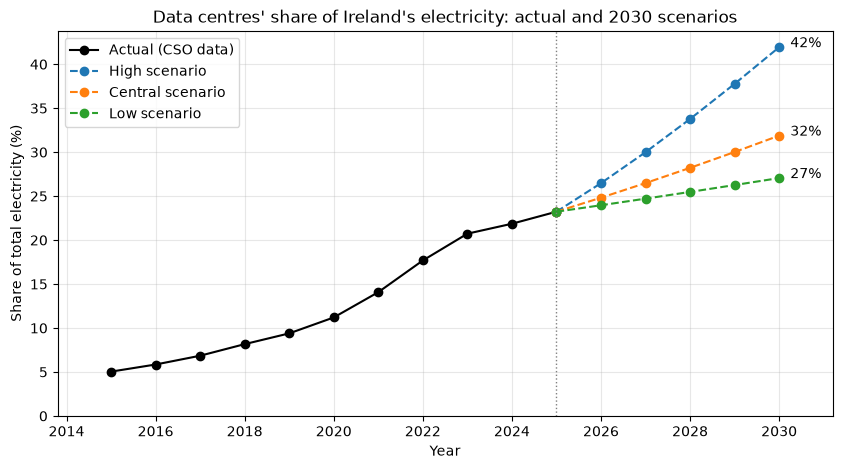

In [22]:
hist_years = yearly.index.astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist_years, yearly["dc_share"], marker="o", color="black", label="Actual (CSO data)")

for name in ["High", "Central", "Low"]:
    s = forecast[forecast["scenario"] == name]
    x = [2025] + list(s["year"])
    y = [yearly["dc_share"].iloc[-1]] + list(s["dc_share"])
    ax.plot(x, y, linestyle="--", marker="o", label=f"{name} scenario")
    ax.annotate(f"{y[-1]:.0f}%", (x[-1], y[-1]), xytext=(8, 0), textcoords="offset points")

ax.axvline(2025, color="grey", linestyle=":", linewidth=1)
ax.set_title("Data centres' share of Ireland's electricity: actual and 2030 scenarios")
ax.set_xlabel("Year")
ax.set_ylabel("Share of total electricity (%)")
ax.set_ylim(bottom=0)
ax.margins(x=0.08)
ax.legend()
ax.grid(alpha=0.3)
plt.savefig("../charts/03_scenarios_2030.png", dpi=150, bbox_inches="tight")
plt.show()

Is clean electricity growing fast enough to cover the extra demand from data centres?

In [23]:
path = "../data/raw/seai_energy_balance.xlsx"
records = []

for year in range(2015, 2026):
    sheet = "2025 Interim" if year == 2025 else str(year)
    sh = pd.read_excel(path, sheet_name=sheet, index_col=0)
    sh.columns = sh.columns.astype(str).str.strip()
    row = sh.loc["Indigenous Production"]
    records.append({"year": year, "hydro": row["Hydro"], "wind": row["Wind"], "solar": row["Solar Photovoltaic"]})

renew = pd.DataFrame(records).set_index("year") * 11.63
renew["clean_total"] = renew.sum(axis=1)
renew.round(0)

,hydro,wind,solar,clean_total
year,,,,
2015,807.0,6683.0,2.0,7491.0
2016,681.0,6250.0,5.0,6936.0
2017,692.0,7568.0,10.0,8270.0
2018,694.0,8784.0,18.0,9496.0
2019,887.0,10187.0,34.0,11107.0
2020,933.0,11742.0,55.0,12730.0
2021,750.0,9941.0,85.0,10776.0
2022,701.0,11396.0,149.0,12246.0
2023,943.0,11865.0,646.0,13455.0


put data centres and clean electricity side by side ! 

In [24]:
yearly_int = yearly.set_index(yearly.index.astype(int))
compare = renew[["clean_total"]].join(yearly_int["data_centres"])

for start in [2015, 2020]:
    added_clean = compare.loc[2025, "clean_total"] - compare.loc[start, "clean_total"]
    added_dc = compare.loc[2025, "data_centres"] - compare.loc[start, "data_centres"]
    print(f"{start} to 2025: clean electricity added {added_clean:,.0f} GWh, data centres added {added_dc:,.0f} GWh")

2015 to 2025: clean electricity added 6,814 GWh, data centres added 6,422 GWh
2020 to 2025: clean electricity added 1,575 GWh, data centres added 4,631 GWh


### Can clean electricity keep up with data centres?

**Data:** clean electricity = wind + solar + hydro from SEAI's National Energy Balance (converted from ktoe to GWh, 1 ktoe = 11.63 GWh). Data centre demand from CSO (MEC02).

**Findings:**
- **2015 to 2025:** Ireland added 6,814 GWh of clean electricity, while data centres added 6,422 GWh of demand. Data centres absorbed about 94% of all new clean electricity built in 10 years.
- **2020 to 2025:** clean electricity grew by only 1,575 GWh (wind was almost flat), while data centres added 4,631 GWh. Data centre demand grew about 3 times faster than clean supply.

**Answer:** since 2020, clean electricity has not kept up with data centre growth. The gap was filled by other sources, mainly gas and imported electricity.


1. Electricity is shared on one grid, so data centres do not use specific sources. This is an accounting comparison of extra demand vs extra clean supply.
2. Wind output depends on the weather. 2020 was a windy year, which makes the 2020 starting point high.
3. Two different sources (CSO and SEAI), and SEAI's 2025 figures are still provisional.
4. Biomass and other bio-renewables are not included, so clean supply is slightly understated.

### The final chart: extra clean electricity vs extra data centre demand, since 2015.

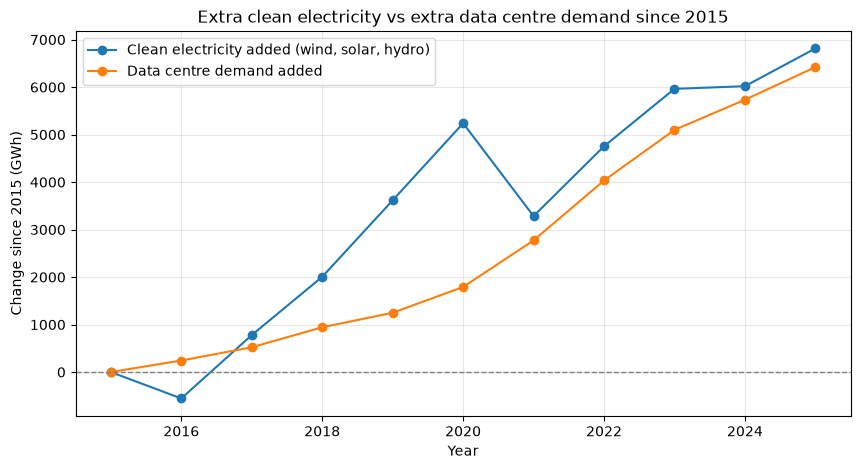

In [25]:
change = compare - compare.loc[2015]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(change.index, change["clean_total"], marker="o", label="Clean electricity added (wind, solar, hydro)")
ax.plot(change.index, change["data_centres"], marker="o", label="Data centre demand added")
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.set_title("Extra clean electricity vs extra data centre demand since 2015")
ax.set_xlabel("Year")
ax.set_ylabel("Change since 2015 (GWh)")
ax.margins(x=0.05)
ax.legend()
ax.grid(alpha=0.3)
plt.savefig("../charts/04_clean_vs_dc.png", dpi=150, bbox_inches="tight")
plt.show()

until 2020, the clean line should be above the data centre line (clean supply growing faster). After 2020, the gap should close, with data centres almost catching up by 2025.

1. The orange line (data centres) climbs smoothly, every single year. Demand is steady and relentless.
2. The blue line (clean electricity) is jagged. It jumps around with the weather: a dip in 2016, a big drop in 2021 (calm years). Clean supply is unpredictable.
3. The gap: in 2020, clean electricity was about 3,400 GWh ahead. By 2025, the lead is down to roughly 400 GWh. Data centres have almost eaten the whole 10-year gain. 